<a href="https://colab.research.google.com/github/laxmisingh01/Optimization-problem/blob/main/task_graph_ga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task Graph Scheduling using Genetic Algorithm

This notebook implements task allocation and bus assignment using a Genetic Algorithm to minimize execution and communication time.

In [4]:
import random

# Inputs
tasks = {'T1': 200, 'T2': 300, 'T3': 150, 'T4': 250}

dependencies = {
    ('T1', 'T2'): 50,
    ('T1', 'T3'): 30,
    ('T2', 'T4'): 40,
    ('T3', 'T4'): 20
}

processors = {
    'P1': {'mips': 1000, 'buses': ['b1']},
    'P2': {'mips': 2000, 'buses': ['b1', 'b2']}
}

buses = {
    'b1': 100,
    'b2': 200
}

In [9]:
# GA Functions

import matplotlib.pyplot as plt

fitness_history = []

for _ in range(GENERATIONS):
    parents = selection(population)
    population = [mutate(crossover(parents[0], parents[1])) for _ in range(POP_SIZE)]

    best = min(population, key=fitness)
    fitness_history.append(fitness(best))

def random_chromosome():
    task_map = {t: random.choice(list(processors.keys())) for t in tasks}
    bus_map = {}

    for edge in dependencies:
        p1 = task_map[edge[0]]
        p2 = task_map[edge[1]]
        common = list(set(processors[p1]['buses']) & set(processors[p2]['buses']))
        bus_map[edge] = random.choice(common if common else list(buses.keys()))

    return {'task_map': task_map, 'bus_map': bus_map}

def fitness(chromo):
    exec_time = sum(tasks[t] / processors[chromo['task_map'][t]]['mips'] for t in tasks)

    comm_time = 0
    for (t1, t2), data in dependencies.items():
        if chromo['task_map'][t1] != chromo['task_map'][t2]:
            bus = chromo['bus_map'][(t1, t2)]
            comm_time += data / buses[bus]

    return exec_time + comm_time

def selection(pop):
    return sorted(pop, key=fitness)[:2]

def crossover(p1, p2):
    return {
        'task_map': {t: random.choice([p1['task_map'][t], p2['task_map'][t]]) for t in tasks},
        'bus_map': {e: random.choice([p1['bus_map'][e], p2['bus_map'][e]]) for e in dependencies}
    }

def mutate(chromo):
    if random.random() < 0.1:
        t = random.choice(list(tasks.keys()))
        chromo['task_map'][t] = random.choice(list(processors.keys()))

    if random.random() < 0.1:
        e = random.choice(list(dependencies.keys()))
        chromo['bus_map'][e] = random.choice(list(buses.keys()))

    return chromo

In [6]:
# Run GA
POP_SIZE = 6
GENERATIONS = 20

population = [random_chromosome() for _ in range(POP_SIZE)]

for _ in range(GENERATIONS):
    parents = selection(population)
    population = [mutate(crossover(parents[0], parents[1])) for _ in range(POP_SIZE)]

best = min(population, key=fitness)

print('Best Task Allocation:', best['task_map'])
print('Best Bus Allocation:', best['bus_map'])
print('Minimum Time:', fitness(best))

Best Task Allocation: {'T1': 'P1', 'T2': 'P1', 'T3': 'P1', 'T4': 'P1'}
Best Bus Allocation: {('T1', 'T2'): 'b1', ('T1', 'T3'): 'b1', ('T2', 'T4'): 'b1', ('T3', 'T4'): 'b1'}
Minimum Time: 0.9


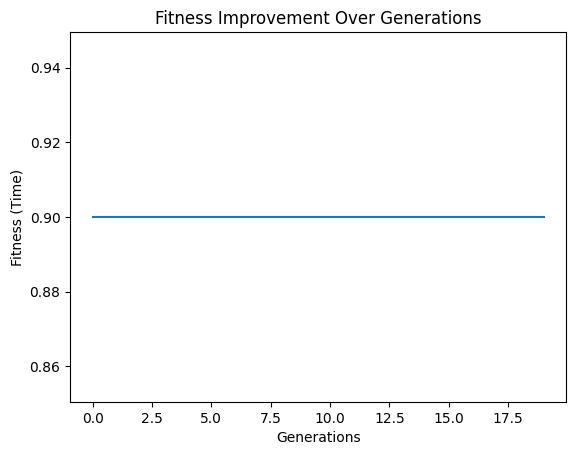

In [10]:
plt.plot(fitness_history)
plt.xlabel("Generations")
plt.ylabel("Fitness (Time)")
plt.title("Fitness Improvement Over Generations")
plt.show()

In [11]:
def time_breakdown(chromo):
    exec_time = 0
    comm_time = 0

    for t in tasks:
        p = chromo['task_map'][t]
        exec_time += tasks[t] / processors[p]['mips']

    for (t1, t2), data in dependencies.items():
        if chromo['task_map'][t1] != chromo['task_map'][t2]:
            bus = chromo['bus_map'][(t1, t2)]
            comm_time += data / buses[bus]

    return exec_time, comm_time

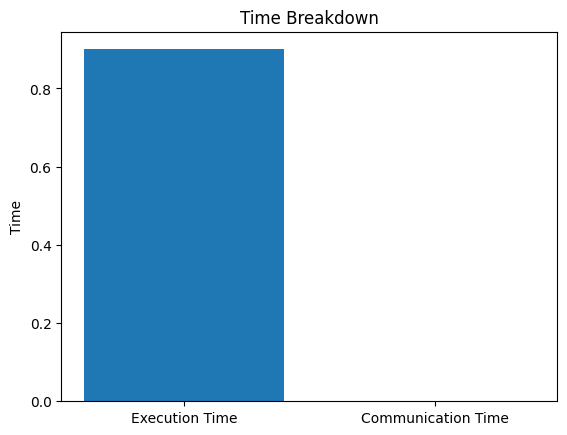

In [12]:
exec_time, comm_time = time_breakdown(best)

plt.bar(['Execution Time', 'Communication Time'], [exec_time, comm_time])
plt.title("Time Breakdown")
plt.ylabel("Time")
plt.show()

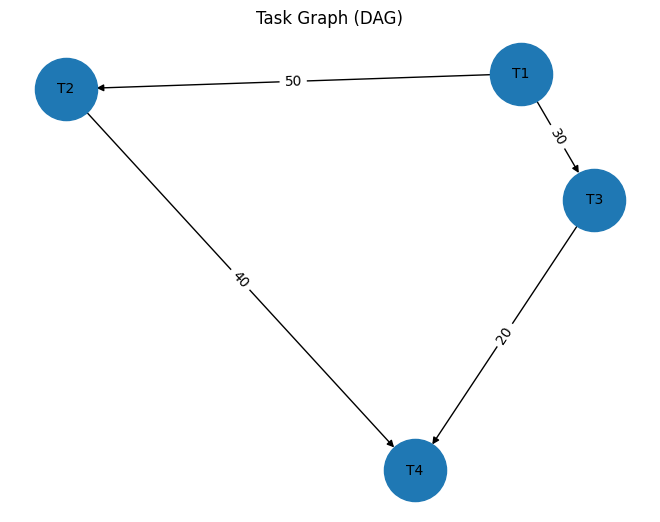

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Add edges with weights
for (t1, t2), data in dependencies.items():
    G.add_edge(t1, t2, weight=data)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Task Graph (DAG)")
plt.show()